# Day 1 — Exploratory Data Analysis (EDA)

**User Engagement Intelligence**

Goal: understand the synthetic user dataset before clustering (Day 2) and churn modeling (Day 3).

We will:
1. Load the data and inspect types / missing values / basic stats
2. Measure overall and segmented churn rates
3. Visualize key relationships (device, recency, correlations)
4. Summarize findings in plain English

## 1. Setup & load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots a bit larger and cleaner by default
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

# Load CSV from the project's data/ folder (path is relative to notebooks/)
df = pd.read_csv("../data/users.csv")

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 10,000 rows x 11 columns


,user_id,age,device_type,sessions_last_30_days,avg_session_duration_minutes,content_views_last_30_days,likes_last_30_days,shares_last_30_days,days_since_last_login,notifications_clicked_last_30_days,churn
0,U00001,22,Android,24,11.0,67,11,2,20,11,0
1,U00002,55,iOS,29,13.4,111,27,2,9,10,0
2,U00003,49,iOS,23,10.2,62,12,0,25,7,0
3,U00004,39,Android,13,6.5,45,6,0,25,4,0
4,U00005,38,Android,14,11.2,36,2,0,29,8,0


## 2. Data quality check

Before modeling, always check: dtypes, missing values, and basic distributions.

In [2]:
# .info() shows column names, non-null counts, and dtypes at a glance
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   user_id                             10000 non-null  object 
 1   age                                 10000 non-null  int64  
 2   device_type                         10000 non-null  object 
 3   sessions_last_30_days               10000 non-null  int64  
 4   avg_session_duration_minutes        10000 non-null  float64
 5   content_views_last_30_days          10000 non-null  int64  
 6   likes_last_30_days                  10000 non-null  int64  
 7   shares_last_30_days                 10000 non-null  int64  
 8   days_since_last_login               10000 non-null  int64  
 9   notifications_clicked_last_30_days  10000 non-null  int64  
 10  churn                               10000 non-null  int64  
dtypes: float64(1), int64(8), object(2)
memory 

In [3]:
# Count missing values per column (should be 0 for this synthetic dataset)
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing cells: {missing.sum()}")

Missing values per column:
user_id                               0
age                                   0
device_type                           0
sessions_last_30_days                 0
avg_session_duration_minutes          0
content_views_last_30_days            0
likes_last_30_days                    0
shares_last_30_days                   0
days_since_last_login                 0
notifications_clicked_last_30_days    0
churn                                 0
dtype: int64

Total missing cells: 0


In [4]:
# .describe() summarizes numeric columns: count, mean, std, min, quartiles, max
df.describe().round(2)

,age,sessions_last_30_days,avg_session_duration_minutes,content_views_last_30_days,likes_last_30_days,shares_last_30_days,days_since_last_login,notifications_clicked_last_30_days,churn
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,41.33,18.32,9.36,52.57,11.52,1.62,24.92,7.58,0.17
std,13.79,8.66,4.53,33.40,10.36,2.17,12.85,4.35,0.37
min,18.00,0.00,0.50,0.00,0.00,0.00,0.00,0.00,0.00
25%,29.00,12.00,6.00,26.00,4.00,0.00,15.00,4.00,0.00
50%,41.00,18.00,9.30,46.00,8.00,1.00,25.00,7.00,0.00
75%,53.00,24.00,12.60,73.00,17.00,2.00,34.00,10.00,0.00
max,65.00,56.00,24.50,215.00,77.00,19.00,71.00,28.00,1.00


In [5]:
# Categorical column: device_type value counts
print("Device mix:")
print(df["device_type"].value_counts())
print("\nDevice mix (proportions):")
# normalize=True turns raw counts into percentages that sum to 1.0
print(df["device_type"].value_counts(normalize=True).round(3))

Device mix:
device_type
Android    4498
iOS        3560
Web        1942
Name: count, dtype: int64

Device mix (proportions):
device_type
Android    0.450
iOS        0.356
Web        0.194
Name: proportion, dtype: float64


## 3. Overall churn rate

In [6]:
# Because churn is 0/1, the mean IS the churn rate
overall_churn = df["churn"].mean()
n_churned = df["churn"].sum()

print(f"Overall churn rate: {overall_churn:.1%} ({n_churned:,} of {len(df):,} users)")

# Quick sanity check of class balance (useful later for modeling)
df["churn"].value_counts().rename({0: "retained", 1: "churned"})

Overall churn rate: 16.6% (1,662 of 10,000 users)


churn
retained    8338
churned     1662
Name: count, dtype: int64

## 4. Churn rate by device type

`groupby("device_type")["churn"].mean()` splits users by device, then averages the 0/1 churn flag in each group — that average is the churn rate for that device.

In [7]:
# Group users by device, then compute mean churn (i.e. churn rate) per group
churn_by_device = (
    df.groupby("device_type")["churn"]
    .agg(churn_rate="mean", n_users="count")  # agg applies multiple stats at once
    .sort_values("churn_rate", ascending=False)
)
churn_by_device["churn_rate_pct"] = (churn_by_device["churn_rate"] * 100).round(1)
churn_by_device

,churn_rate,n_users,churn_rate_pct
device_type,,,
Web,0.270855,1942,27.1
Android,0.155625,4498,15.6
iOS,0.122472,3560,12.2


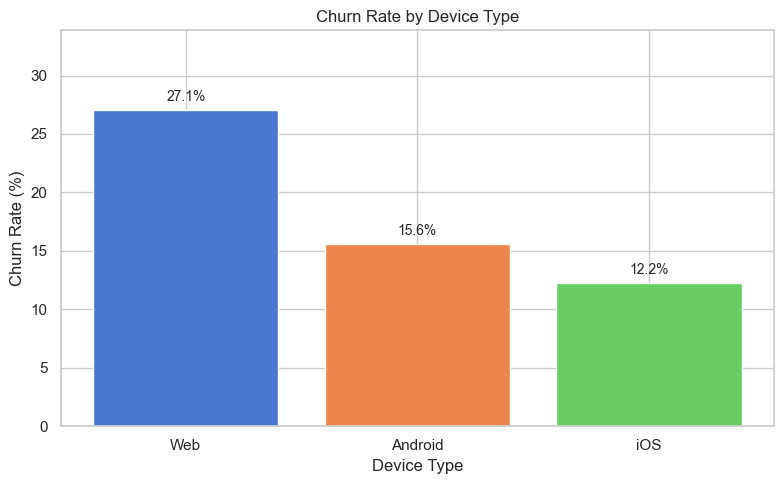

In [8]:
fig, ax = plt.subplots()

# Plot churn rate (%) as bars — order matches the sorted table above
bars = ax.bar(
    churn_by_device.index,
    churn_by_device["churn_rate"] * 100,
    color=sns.color_palette("muted", n_colors=len(churn_by_device)),
)

ax.set_title("Churn Rate by Device Type")
ax.set_xlabel("Device Type")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, max(churn_by_device["churn_rate"] * 100) * 1.25)

# Annotate each bar with its percentage so the chart is self-explanatory
for bar, pct in zip(bars, churn_by_device["churn_rate"] * 100):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

## 5. Churn rate by engagement level (binned sessions)

We bin `sessions_last_30_days` into Low / Medium / High using quantiles (`pd.qcut`), then compare churn across those buckets.

In [9]:
# pd.qcut splits a numeric column into equal-sized groups based on quantiles.
# duplicates="drop" handles the rare case where many users share the same value.
df["engagement_level"] = pd.qcut(
    df["sessions_last_30_days"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop",
)

# Show how many users fall into each bin and the session range
print("Users per engagement bin:")
print(df["engagement_level"].value_counts().sort_index())
print("\nSession range per bin:")
# groupby().agg() computes min/max sessions inside each engagement bin
print(
    df.groupby("engagement_level", observed=True)["sessions_last_30_days"]
    .agg(min_sessions="min", max_sessions="max", avg_sessions="mean")
    .round(1)
)

Users per engagement bin:
engagement_level
Low       3672
Medium    3213
High      3115
Name: count, dtype: int64

Session range per bin:
                  min_sessions  max_sessions  avg_sessions
engagement_level                                          
Low                          0            14           9.5
Medium                      15            22          18.3
High                        23            56          28.7


In [10]:
# Churn rate by engagement level — expect Low >> High if the data is learnable
churn_by_engagement = (
    df.groupby("engagement_level", observed=True)["churn"]
    .agg(churn_rate="mean", n_users="count")
)
churn_by_engagement["churn_rate_pct"] = (churn_by_engagement["churn_rate"] * 100).round(1)
churn_by_engagement

,churn_rate,n_users,churn_rate_pct
engagement_level,,,
Low,0.399782,3672,40.0
Medium,0.058512,3213,5.9
High,0.001926,3115,0.2


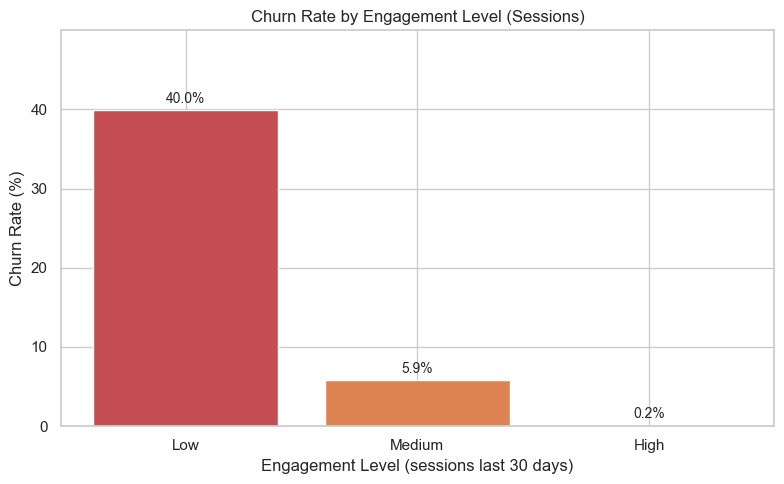

In [11]:
fig, ax = plt.subplots()

order = ["Low", "Medium", "High"]
rates = churn_by_engagement.loc[order, "churn_rate"] * 100

bars = ax.bar(order, rates, color=["#c44e52", "#dd8452", "#55a868"])
ax.set_title("Churn Rate by Engagement Level (Sessions)")
ax.set_xlabel("Engagement Level (sessions last 30 days)")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, max(rates) * 1.25)

for bar, pct in zip(bars, rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

## 6. Distribution of days since last login (split by churn)

If churners tend to have longer gaps since last login, the two histograms should separate visually.

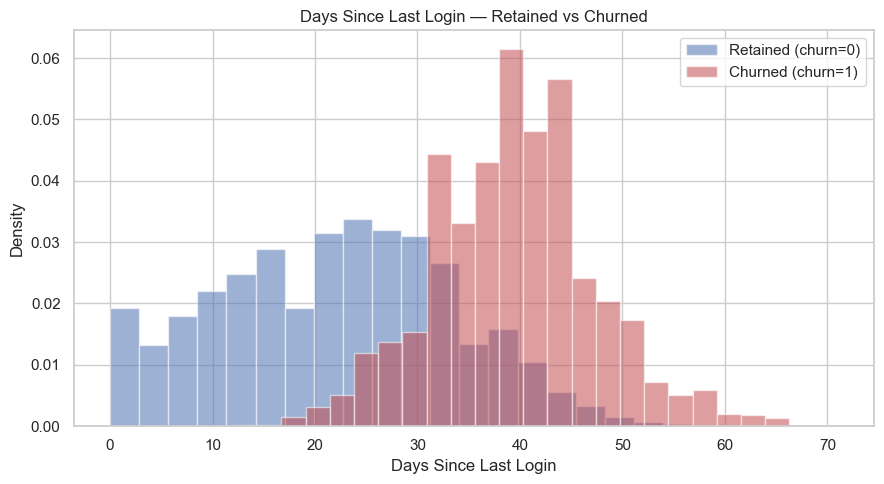

Mean days_since_last_login by churn:
churn
retained    22.0
churned     39.4
Name: days_since_last_login, dtype: float64


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

# Overlay two histograms: retained (churn=0) vs churned (churn=1)
# alpha makes overlapping bars see-through; density=True compares shapes fairly
# even when class sizes differ
for label, subset, color in [
    ("Retained (churn=0)", df[df["churn"] == 0], "#4c72b0"),
    ("Churned (churn=1)", df[df["churn"] == 1], "#c44e52"),
]:
    ax.hist(
        subset["days_since_last_login"],
        bins=25,
        alpha=0.55,
        label=label,
        color=color,
        density=True,
        edgecolor="white",
    )

ax.set_title("Days Since Last Login — Retained vs Churned")
ax.set_xlabel("Days Since Last Login")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

# Numeric confirmation of the visual pattern
print("Mean days_since_last_login by churn:")
print(df.groupby("churn")["days_since_last_login"].mean().round(1).rename({0: "retained", 1: "churned"}))

## 7. Correlation heatmap (numeric features)

Pearson correlation ranges from -1 to +1. Strong positive = features rise together; strong negative = one rises as the other falls. Look especially at how engagement features correlate with `churn`.

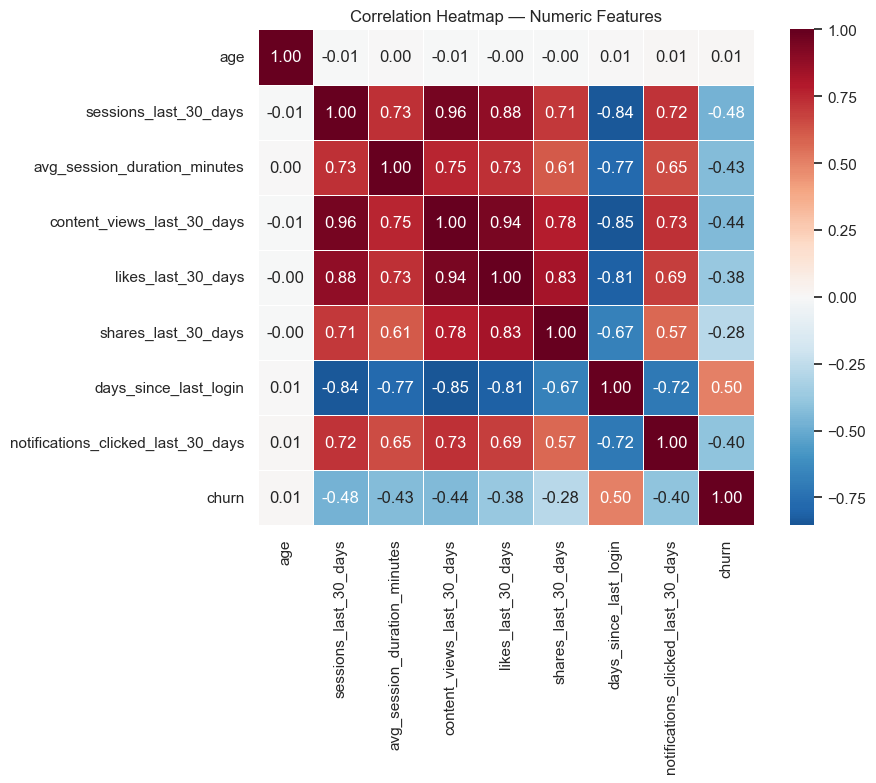

Features most correlated with churn (|r| descending):
days_since_last_login                 0.505
sessions_last_30_days                -0.476
content_views_last_30_days           -0.436
avg_session_duration_minutes         -0.433
notifications_clicked_last_30_days   -0.400
likes_last_30_days                   -0.379
shares_last_30_days                  -0.281
age                                   0.014
Name: churn, dtype: float64


In [13]:
# Select only numeric columns for the correlation matrix
numeric_cols = [
    "age",
    "sessions_last_30_days",
    "avg_session_duration_minutes",
    "content_views_last_30_days",
    "likes_last_30_days",
    "shares_last_30_days",
    "days_since_last_login",
    "notifications_clicked_last_30_days",
    "churn",
]

# .corr() builds a pairwise Pearson correlation matrix
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,          # write correlation values inside each cell
    fmt=".2f",            # round annotations to 2 decimal places
    cmap="RdBu_r",        # red = positive, blue = negative
    center=0,            # keep 0 (no correlation) as the neutral color
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

# Rank features by absolute correlation with churn (quick interview talking point)
churn_corr = corr["churn"].drop("churn").sort_values(key=abs, ascending=False)
print("Features most correlated with churn (|r| descending):")
print(churn_corr.round(3))

## 8. Quick feature comparison: churned vs retained

Side-by-side means help confirm that low engagement + high recency gaps line up with churn.

In [14]:
feature_cols = [
    "sessions_last_30_days",
    "avg_session_duration_minutes",
    "content_views_last_30_days",
    "likes_last_30_days",
    "shares_last_30_days",
    "days_since_last_login",
    "notifications_clicked_last_30_days",
]

# groupby("churn").mean() averages each feature separately for retained vs churned users
profile = df.groupby("churn")[feature_cols].mean().round(2)
profile.index = profile.index.map({0: "retained", 1: "churned"})
profile.T  # transpose so features are rows — easier to scan

churn,retained,churned
sessions_last_30_days,20.16,9.09
avg_session_duration_minutes,10.24,4.96
content_views_last_30_days,59.07,19.93
likes_last_30_days,13.27,2.72
shares_last_30_days,1.90,0.25
days_since_last_login,22.03,39.45
notifications_clicked_last_30_days,8.36,3.68


## Key findings (Day 1)

1. **Churn is uncommon but measurable** — roughly one in six users churn in this dataset, so class imbalance exists but is not extreme. Models on Day 3 should still see both classes clearly.

2. **Device matters** — Web users churn at a noticeably higher rate than Android or iOS users. Device type is a useful categorical signal for later models (after one-hot encoding).

3. **Engagement strongly separates churners** — Low-session users churn far more often than Medium/High-session users. Churned users also show shorter sessions, fewer views/likes/shares/notification clicks, and **much longer** gaps since last login.

4. **Features are correlated in a learnable way** — Engagement metrics move together (positive correlations), while `days_since_last_login` is positively correlated with churn and negatively correlated with sessions/views. That structure means Day 2 clustering and Day 3 classifiers should have real signal to work with — not random noise.

**Data quality note:** No missing values; dtypes look correct. No cleaning steps required beyond what we already have for Day 1. Ready for clustering on Day 2.